# Milestone 6 — Part 1: RAG Pipeline
**MLOps Course | Module 7**

This notebook implements a complete Retrieval-Augmented Generation pipeline:
1. Document ingestion and chunking
2. Embedding generation (`all-MiniLM-L6-v2`)
3. Vector index creation (FAISS `IndexFlatIP`)
4. Retrieval query execution
5. Grounded answer generation (Ollama `mistral:7b-instruct`)
6. Evaluation on 10 handcrafted queries (Precision@k, Recall@k, latency)

**Model:** `mistral:7b-instruct` via Ollama (7B, 4-bit quantised)  
**Vector DB:** FAISS (open-source, in-memory)  
**Pre-requisite:** `ollama serve` running and `ollama pull mistral:7b-instruct` completed.

## 1. Environment Setup

In [1]:
# Install required packages (run once)
import sys
!{sys.executable} -m pip install -q faiss-cpu==1.8.0 sentence-transformers==2.7.0 ollama==0.2.1 \
    numpy==1.26.4 pandas==2.2.2 tqdm==4.66.4 tabulate==0.9.0 matplotlib==3.9.0

zsh:1: no such file or directory: /Users/kiran14/Documents/IDS


In [2]:
import json
import re
import time
import warnings
from pathlib import Path
from typing import Dict, Any, List, Tuple, Optional

import numpy as np
import pandas as pd
import faiss
import matplotlib.pyplot as plt
from tqdm import tqdm
from tabulate import tabulate
from sentence_transformers import SentenceTransformer
import ollama

warnings.filterwarnings('ignore')
print('All imports OK.')

/Users/kiran14/Documents/IDS 568/IDS-milstone6/ids568-milestone6-kiran/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


All imports OK.


In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
MODEL_NAME    = 'mistral:7b-instruct'   # Ollama model
EMBED_MODEL   = 'all-MiniLM-L6-v2'     # sentence-transformers
CHUNK_SIZE    = 512                     # characters
CHUNK_OVERLAP = 100                     # characters
TOP_K         = 3                       # chunks retrieved per query

# Verify Ollama is reachable
try:
    models = ollama.list()
    names  = [m['name'] for m in models.get('models', [])]
    if any(MODEL_NAME in n for n in names):
        print(f'Ollama OK — model "{MODEL_NAME}" is available.')
    else:
        print(f'WARNING: {MODEL_NAME} not found. Run: ollama pull {MODEL_NAME}')
        print(f'Available: {names}')
except Exception as e:
    print(f'ERROR: Cannot reach Ollama — {e}')
    print('Please start Ollama: ollama serve')

Ollama OK — model "mistral:7b-instruct" is available.


## 2. Document Corpus

We use 10 MLOps/AI domain documents (each ~500–700 words) as the knowledge base.
Topics span RAG, vector databases, LLM deployment, evaluation, chunking, fine-tuning,
MLOps practices, monitoring, embeddings, and prompt engineering.

In [4]:
DOCUMENTS = {
    'doc_01': {
        'title': 'Retrieval-Augmented Generation (RAG)',
        'content': (
            'Retrieval-Augmented Generation (RAG) is an AI framework that enhances large language models '
            'by dynamically retrieving relevant information from an external knowledge base at inference time. '
            'Unlike purely parametric models that rely solely on information encoded during training, RAG systems '
            'combine neural retrieval with language model generation to produce responses grounded in factual, '
            'verifiable sources.\n\n'
            'The RAG pipeline operates in four main stages. First, documents are ingested and split into smaller '
            'chunks using a chunking strategy. Second, each chunk is encoded into a dense embedding vector. Third, '
            'when a user query arrives, it is also embedded and the most relevant chunks are retrieved via vector '
            'similarity search. Fourth, the retrieved chunks are concatenated with the query, and the language model '
            'generates a grounded answer.\n\n'
            'Benefits of RAG include reduced hallucination because responses are grounded in retrieved evidence, '
            'knowledge currency since retrieval corpora can be updated without retraining, source attribution for '
            'verifiable outputs, and cost efficiency since knowledge updates require only corpus changes. RAG is widely '
            'used for question answering over private documents, technical support, and knowledge-intensive NLP tasks.\n\n'
            'Common failure modes include retrieval failures when relevant documents are not retrieved, context window '
            'overflow with too many chunks, and generation errors where the LLM ignores retrieved context. Proper '
            'evaluation must measure both retrieval accuracy and generation faithfulness separately.'
        ),
    },
    'doc_02': {
        'title': 'Vector Databases and Similarity Search',
        'content': (
            'Vector databases are specialized storage systems designed to index and query high-dimensional embedding '
            'vectors efficiently. They form the backbone of modern RAG systems by enabling fast semantic similarity '
            'search across large document collections.\n\n'
            'FAISS (Facebook AI Similarity Search) is an open-source library for efficient similarity search supporting '
            'both exact and approximate nearest neighbor search. It offers multiple index types: IndexFlatL2 for exact '
            'Euclidean search, IndexFlatIP for inner product (cosine similarity after normalization), IndexIVFFlat for '
            'inverted file approximate search, and HNSW for graph-based approximate search. FAISS is optimal for '
            'in-memory workloads requiring low latency.\n\n'
            'ChromaDB is a purpose-built open-source vector database with persistent storage, metadata filtering, and '
            'a simple Python API. It supports cosine and L2 distance metrics and integrates directly with LangChain '
            'and LlamaIndex. Chroma is ideal when persistence and metadata filtering are required.\n\n'
            'Weaviate provides hybrid search combining vector similarity with BM25 keyword search. Qdrant offers '
            'HNSW-based indexing with payload filtering. For most RAG prototypes, FAISS provides the best '
            'performance-to-setup-complexity ratio, while Chroma offers better developer experience with built-in '
            'persistence.'
        ),
    },
    'doc_03': {
        'title': 'LLM Deployment and Serving',
        'content': (
            'Deploying large language models for inference requires careful consideration of hardware constraints, '
            'latency requirements, and serving frameworks. Several options exist for local and self-hosted LLM inference.\n\n'
            'Ollama is a lightweight tool for running open-weight models locally. It handles model downloading, '
            'quantization, and provides a REST API. Ollama supports models including Mistral, Llama, Qwen, and Gemma '
            'families. Installation is straightforward: download Ollama, then run ollama pull mistral:7b-instruct. '
            'The Python client allows chat completions via ollama.chat().\n\n'
            'vLLM is a high-throughput serving framework optimized for GPU inference using PagedAttention for efficient '
            'KV cache management. It achieves 10-24x higher throughput than naive implementations and supports continuous '
            'batching. vLLM is ideal for production deployments on GPU servers.\n\n'
            'Hugging Face Transformers provides direct model loading using AutoModelForCausalLM and AutoTokenizer. '
            'Text Generation Inference (TGI) is Hugging Face production serving stack supporting tensor parallelism. '
            'For 7B models on consumer hardware: Apple Silicon M-series chips can run 7B models at 10-20 tokens per second '
            'using Ollama with Metal acceleration. NVIDIA GPUs with 8GB+ VRAM achieve 50-100 tokens per second. '
            'CPU-only inference is possible but slow at 1-3 tokens per second.'
        ),
    },
    'doc_04': {
        'title': 'RAG Evaluation Metrics',
        'content': (
            'Evaluating RAG systems requires measuring both retrieval quality and generation faithfulness separately, '
            'as failures in either stage lead to poor overall performance.\n\n'
            'For retrieval evaluation, precision@k measures the fraction of retrieved documents in the top k that are '
            'relevant. Recall@k measures the fraction of all relevant documents retrieved in the top k. Mean Reciprocal '
            'Rank (MRR) measures the average inverse rank of the first relevant document. Normalized Discounted '
            'Cumulative Gain (nDCG) accounts for graded relevance and position.\n\n'
            'For generation evaluation, RAGAS is a framework specifically designed for RAG evaluation with metrics '
            'including faithfulness (is the answer supported by retrieved context?), answer relevance, context precision, '
            'and context recall. Faithfulness is computed by checking if each claim in the generated answer is supported '
            'by the retrieved context.\n\n'
            'For hallucination detection, compare the generated answer against retrieved context to identify claims made '
            'without supporting evidence. BERTScore measures semantic similarity between generated and reference answers. '
            'End-to-end latency must be decomposed into embedding latency, vector search latency, and generation latency '
            'to identify bottlenecks. Typical targets are retrieval under 100ms and generation under 10 seconds.'
        ),
    },
    'doc_05': {
        'title': 'Text Chunking Strategies for RAG',
        'content': (
            'Chunking is one of the most important design decisions in a RAG pipeline. The chunk size and overlap '
            'strategy directly affect retrieval quality by determining what information is co-located in a single '
            'retrievable unit.\n\n'
            'Fixed-size character chunking splits text into segments of a specified character count with optional overlap '
            'between adjacent chunks. This approach is simple to implement and provides consistent chunk sizes. The overlap '
            'prevents important information from being split at chunk boundaries. Typical parameters are 256-1024 characters '
            'with 10-20% overlap. Smaller chunks improve retrieval precision but may lack sufficient context for generation.\n\n'
            'Recursive character text splitting attempts to split on semantic boundaries (paragraphs, then sentences, then '
            'words) before falling back to character splits. This preserves natural text structure better than pure '
            'character splitting.\n\n'
            'Semantic chunking uses embedding similarity to identify natural topic boundaries, grouping sentences that are '
            'semantically related. This produces variable-size chunks that better capture complete thoughts but is '
            'computationally expensive. For technical documents, fixed-size chunking with 512 characters and 100-character '
            'overlap provides a good balance: chunks are large enough to contain meaningful information, small enough for '
            'precise retrieval, and the overlap handles boundary cases.'
        ),
    },
    'doc_06': {
        'title': 'Transfer Learning and Parameter-Efficient Fine-tuning',
        'content': (
            'Transfer learning enables reuse of pretrained model knowledge for new tasks by fine-tuning on task-specific '
            'data. For large language models, full fine-tuning is computationally expensive, leading to parameter-efficient '
            'fine-tuning (PEFT) methods.\n\n'
            'Low-Rank Adaptation (LoRA) adds trainable low-rank decomposition matrices to frozen transformer weight '
            'matrices. If a weight matrix W has dimension d by d, LoRA represents the update as delta W equals A times B '
            'where A has dimensions d by r and B has dimensions r by d with r much less than d. This reduces trainable '
            'parameters by 99 percent compared to full fine-tuning while achieving comparable performance.\n\n'
            'QLoRA combines LoRA with 4-bit quantization of the base model weights. The base model is quantized to NF4 '
            'format, reducing memory by 75 percent, while LoRA adapters remain in full precision. This enables fine-tuning '
            '7B models on a single 24GB GPU.\n\n'
            'Instruction tuning trains models on instruction-response pairs to follow natural language instructions. '
            'Reinforcement Learning from Human Feedback (RLHF) aligns models with human preferences using a reward model. '
            'Direct Preference Optimization (DPO) achieves similar alignment without explicit reward modeling.'
        ),
    },
    'doc_07': {
        'title': 'MLOps Best Practices',
        'content': (
            'MLOps encompasses practices for deploying, monitoring, and maintaining machine learning models in production. '
            'It bridges the gap between ML development and software engineering practices.\n\n'
            'Experiment tracking with tools like MLflow, Weights and Biases, or DVC enables reproducibility by logging '
            'hyperparameters, metrics, artifacts, and code versions for every training run. Reproducibility requires pinning '
            'random seeds, documenting hardware configurations, and version-controlling datasets.\n\n'
            'Model versioning using model registries enables promotion of models through development, staging, and production '
            'stages with associated metadata. Each model version should include training data lineage, evaluation metrics, '
            'and deployment constraints.\n\n'
            'CI/CD for ML automates testing, training, and deployment pipelines. Data validation tests verify schema and '
            'statistical properties of new data. Feature stores centralize feature computation and serving, ensuring '
            'training-serving consistency. Container-based deployment with Docker ensures environment consistency between '
            'development and production. Kubernetes enables scalable serving with automatic scaling and rolling deployments.'
        ),
    },
    'doc_08': {
        'title': 'Monitoring ML Models in Production',
        'content': (
            'Production ML systems require continuous monitoring to detect performance degradation caused by data drift, '
            'concept drift, or infrastructure issues. Without monitoring, model quality can silently degrade.\n\n'
            'Data drift occurs when the statistical distribution of input features shifts from the training distribution. '
            'Detection methods include population stability index (PSI), Kolmogorov-Smirnov test for continuous features, '
            'chi-squared test for categorical features, and Maximum Mean Discrepancy (MMD). Tools like Evidently AI, '
            'WhyLogs, and Great Expectations automate drift detection.\n\n'
            'Concept drift occurs when the relationship between input features and target labels changes even if input '
            'distribution remains stable. This requires monitoring prediction accuracy and model performance metrics over time.\n\n'
            'For LLM monitoring, track input and output token distributions, response latency, error rates, and user '
            'feedback signals. Hallucination monitoring uses embedding similarity between retrieved context and generated '
            'responses. LangSmith and Arize Phoenix provide LLM-specific observability. Alerting should use Prometheus '
            'with Grafana dashboards. Shadow mode deployment runs new model versions alongside production for safe comparison.'
        ),
    },
    'doc_09': {
        'title': 'Sentence Embeddings and Semantic Search',
        'content': (
            'Sentence embeddings are dense vector representations that capture the semantic meaning of text in a continuous '
            'high-dimensional space. Semantically similar sentences are mapped to nearby vectors, enabling efficient '
            'semantic similarity computation.\n\n'
            'The sentence-transformers library (SBERT) provides pretrained models optimized for sentence-level semantic '
            'similarity. Models like all-MiniLM-L6-v2 (384 dimensions, 22M parameters) offer an excellent balance of speed '
            'and quality for English text. all-mpnet-base-v2 (768 dimensions) provides higher quality.\n\n'
            'SBERT trains using a siamese network structure with contrastive learning objectives. The model encodes two '
            'sentences and optimizes cosine similarity to be high for semantically related pairs and low for unrelated '
            'pairs. This produces embeddings where cosine similarity directly reflects semantic similarity.\n\n'
            'For semantic search, query and document embeddings are precomputed. At query time, the query embedding is '
            'computed and cosine similarity is measured against all document embeddings. FAISS enables sub-linear search '
            'with approximate methods for large corpora. Domain-specific embedding models often outperform general-purpose '
            'models on specialized corpora.'
        ),
    },
    'doc_10': {
        'title': 'Prompt Engineering Techniques',
        'content': (
            'Prompt engineering is the practice of designing input prompts to elicit desired behaviors from large language '
            'models. Effective prompting can significantly improve model performance without any parameter updates.\n\n'
            'Zero-shot prompting directly asks the model to perform a task without examples. Few-shot prompting includes '
            '2-8 input-output examples in the prompt to demonstrate the desired format and behavior.\n\n'
            'Chain-of-thought (CoT) prompting encourages models to generate intermediate reasoning steps before producing '
            'a final answer. Adding phrases like Let us think step by step significantly improves performance on multi-step '
            'reasoning tasks, arithmetic, and logical inference. CoT is most effective for models above 10B parameters.\n\n'
            'Self-consistency sampling runs the model multiple times with temperature above 0 and takes the majority vote '
            'among generated answers. This improves CoT accuracy by 10-20 percent at the cost of multiple inference calls. '
            'System prompts establish the model persona, constraints, and behavior. For RAG prompts, explicitly instructing '
            'the model to answer only from provided context reduces hallucination. Including an if the context does not '
            'contain this information say so instruction improves groundedness.'
        ),
    },
}

print(f'Corpus loaded: {len(DOCUMENTS)} documents')
for doc_id, doc in DOCUMENTS.items():
    print(f'  {doc_id}: "{doc["title"]}" ({len(doc["content"])} chars)')

Corpus loaded: 10 documents
  doc_01: "Retrieval-Augmented Generation (RAG)" (1556 chars)
  doc_02: "Vector Databases and Similarity Search" (1314 chars)
  doc_03: "LLM Deployment and Serving" (1343 chars)
  doc_04: "RAG Evaluation Metrics" (1317 chars)
  doc_05: "Text Chunking Strategies for RAG" (1390 chars)
  doc_06: "Transfer Learning and Parameter-Efficient Fine-tuning" (1219 chars)
  doc_07: "MLOps Best Practices" (1177 chars)
  doc_08: "Monitoring ML Models in Production" (1241 chars)
  doc_09: "Sentence Embeddings and Semantic Search" (1220 chars)
  doc_10: "Prompt Engineering Techniques" (1242 chars)


## 3. Chunking Strategy

**Choice:** Fixed-size character chunking with overlap.

| Parameter | Value | Justification |
|-----------|-------|---------------|
| `chunk_size` | 512 chars | Captures a complete conceptual unit (~80–120 words) |
| `overlap` | 100 chars (~20%) | Prevents concepts from being split at boundaries |

We tested 256, 512, and 1024-char chunks on a pilot query set:
- **256**: Too granular — splits ideas mid-sentence; lower generation quality.
- **512**: Best balance of retrieval precision and generation context.
- **1024**: Mixes multiple topics in one chunk; lower retrieval precision.

Sentence-based or semantic chunking would be alternatives, but they require additional
dependencies (NLTK, spaCy) or extra embedding passes, adding complexity with marginal
gain for this 10-document corpus.

In [5]:
def chunk_text(text: str, chunk_size: int = CHUNK_SIZE, overlap: int = CHUNK_OVERLAP) -> List[str]:
    """Fixed-size character chunking with overlap."""
    chunks: List[str] = []
    start = 0
    while start < len(text):
        end = min(start + chunk_size, len(text))
        chunk = text[start:end].strip()
        if chunk:
            chunks.append(chunk)
        if end >= len(text):
            break
        start += chunk_size - overlap   # slide forward with overlap
    return chunks


# Build the flat chunk list with metadata
all_chunks: List[Dict[str, Any]] = []
for doc_id, doc in DOCUMENTS.items():
    for i, text in enumerate(chunk_text(doc['content'])):
        all_chunks.append({
            'chunk_id':  f'{doc_id}_chunk_{i}',
            'doc_id':    doc_id,
            'doc_title': doc['title'],
            'text':      text,
        })

print(f'Total chunks: {len(all_chunks)}')
print(f'Avg chunk length: {np.mean([len(c["text"]) for c in all_chunks]):.0f} chars')

# Show distribution
chunks_per_doc = {}
for c in all_chunks:
    chunks_per_doc[c['doc_id']] = chunks_per_doc.get(c['doc_id'], 0) + 1
print('\nChunks per document:')
for doc_id, n in chunks_per_doc.items():
    print(f'  {doc_id}: {n} chunk(s)')

Total chunks: 33
Avg chunk length: 464 chars

Chunks per document:
  doc_01: 4 chunk(s)
  doc_02: 3 chunk(s)
  doc_03: 4 chunk(s)
  doc_04: 3 chunk(s)
  doc_05: 4 chunk(s)
  doc_06: 3 chunk(s)
  doc_07: 3 chunk(s)
  doc_08: 3 chunk(s)
  doc_09: 3 chunk(s)
  doc_10: 3 chunk(s)


## 4. Embedding Generation

**Model:** `sentence-transformers/all-MiniLM-L6-v2`
- 384-dimensional embeddings
- 22M parameters — fast and lightweight
- L2-normalised → cosine similarity via FAISS `IndexFlatIP` (inner product)
- Batch size 32 for CPU efficiency

In [6]:
print(f'Loading embedding model: {EMBED_MODEL} …')
embed_model = SentenceTransformer(EMBED_MODEL)

texts = [c['text'] for c in all_chunks]

t0 = time.time()
embeddings = embed_model.encode(texts, show_progress_bar=True, batch_size=32,
                                convert_to_numpy=True)
embed_time = time.time() - t0

embeddings = embeddings.astype(np.float32)
faiss.normalize_L2(embeddings)          # in-place L2 normalisation for cosine sim

print(f'\nEmbedding shape : {embeddings.shape}')
print(f'Embedding dtype : {embeddings.dtype}')
print(f'Total encode time : {embed_time*1000:.0f} ms  '
      f'({embed_time/len(texts)*1000:.1f} ms/chunk)')

Loading embedding model: all-MiniLM-L6-v2 …


Batches:   0%|          | 0/2 [00:00<?, ?it/s]


Embedding shape : (33, 384)
Embedding dtype : float32
Total encode time : 1003 ms  (30.4 ms/chunk)


## 5. Vector Index (FAISS)

We use `IndexFlatIP` (exact inner product) because:
- Our corpus has ~36 vectors — exact search is sub-millisecond.
- After L2 normalisation, inner product equals cosine similarity.
- No need for IVF or HNSW approximate indexes at this scale.

In [7]:
dimension = embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)
index.add(embeddings)

print(f'FAISS index: IndexFlatIP')
print(f'Vectors stored : {index.ntotal}')
print(f'Dimension      : {dimension}')

# Optionally persist the index
faiss.write_index(index, 'rag_index.faiss')
print('Index saved to rag_index.faiss')

FAISS index: IndexFlatIP
Vectors stored : 33
Dimension      : 384
Index saved to rag_index.faiss


## 6. Retrieval

In [8]:
def retrieve(query: str, k: int = TOP_K) -> Tuple[List[Dict[str, Any]], float]:
    """
    Retrieve top-k relevant chunks for a query.
    Returns (list_of_result_dicts, latency_ms).
    """
    t0 = time.time()
    q_emb = embed_model.encode([query], convert_to_numpy=True).astype(np.float32)
    faiss.normalize_L2(q_emb)
    scores, indices = index.search(q_emb, k)
    latency_ms = (time.time() - t0) * 1000

    results = []
    for score, idx in zip(scores[0], indices[0]):
        if idx >= 0:
            chunk = all_chunks[int(idx)]
            results.append({**chunk, 'score': float(score)})
    return results, latency_ms


# Quick smoke test
test_query = 'What are the benefits of RAG?'
test_results, test_latency = retrieve(test_query)

print(f'Query: "{test_query}"')
print(f'Retrieval latency: {test_latency:.1f} ms\n')
for i, r in enumerate(test_results, 1):
    print(f'  [{i}] {r["doc_title"]} | score={r["score"]:.3f}')
    print(f'      {r["text"][:100]}…')
    print()

Query: "What are the benefits of RAG?"
Retrieval latency: 162.4 ms

  [1] Retrieval-Augmented Generation (RAG) | score=0.597
      es a grounded answer.

Benefits of RAG include reduced hallucination because responses are grounded …

  [2] Retrieval-Augmented Generation (RAG) | score=0.412
      e RAG pipeline operates in four main stages. First, documents are ingested and split into smaller ch…

  [3] Text Chunking Strategies for RAG | score=0.332
      Chunking is one of the most important design decisions in a RAG pipeline. The chunk size and overlap…



## 7. LLM Integration (Ollama — mistral:7b-instruct)

The generator receives retrieved chunks as context and is instructed to answer
**only** from that context. This reduces hallucination by enforcing grounding.

**Model setup:**
```bash
ollama pull mistral:7b-instruct   # ~4 GB download
ollama serve                       # starts REST server on port 11434
```

**Serving details:** 4-bit quantised (Q4_0), Apple M2 Pro + Metal acceleration,
typical latency 8–15 s per response (~15 tokens/s).

In [9]:
RAG_PROMPT_TEMPLATE = """\
You are a helpful assistant. Answer the following question using ONLY the provided context.
If the context does not contain sufficient information to answer the question, say:
"The retrieved context does not contain enough information to answer this question."
Do not add information that is not present in the context.

Context:
{context}

Question: {question}

Answer (grounded in the context above):"""


def generate_answer(query: str, retrieved: List[Dict[str, Any]],
                    model: str = MODEL_NAME) -> Tuple[str, float]:
    """
    Generate a grounded answer using retrieved context.
    Returns (answer_text, latency_seconds).
    """
    context = '\n\n---\n\n'.join(
        f'Source: {r["doc_title"]}\n{r["text"]}' for r in retrieved
    )
    prompt = RAG_PROMPT_TEMPLATE.format(context=context, question=query)

    t0 = time.time()
    response = ollama.chat(
        model=model,
        messages=[{'role': 'user', 'content': prompt}],
    )
    latency = time.time() - t0
    return response['message']['content'].strip(), latency


# Smoke-test generation
print('Testing LLM generation …')
test_answer, test_gen_latency = generate_answer(test_query, test_results)
print(f'Generation latency: {test_gen_latency:.1f} s')
print(f'\nAnswer:\n{test_answer}')

Testing LLM generation …


Generation latency: 7.4 s

Answer:
Reduced hallucination because responses are grounded in retrieved evidence, knowledge currency since retrieval corpora can be updated without retraining, source attribution for verifiable outputs, and cost efficiency since knowledge updates require only corpus changes.


## 8. Full RAG Pipeline

In [10]:
def rag_pipeline(query: str, k: int = TOP_K) -> Dict[str, Any]:
    """End-to-end RAG: retrieve → generate → measure latency."""
    t_start = time.time()

    # Stage 1: Retrieval
    retrieved, retrieval_ms = retrieve(query, k=k)

    # Stage 2: Generation
    answer, gen_sec = generate_answer(query, retrieved)

    end_to_end_ms = (time.time() - t_start) * 1000

    return {
        'query':           query,
        'retrieved_chunks': retrieved,
        'answer':          answer,
        'latencies': {
            'retrieval_ms':    round(retrieval_ms, 2),
            'generation_ms':   round(gen_sec * 1000, 2),
            'end_to_end_ms':   round(end_to_end_ms, 2),
        },
    }


# Demo run
demo = rag_pipeline('How does LoRA reduce the number of trainable parameters?')
print('Query:', demo['query'])
print('Retrieved docs:', [r['doc_title'] for r in demo['retrieved_chunks']])
print('\nAnswer:', demo['answer'])
print('\nLatencies:', demo['latencies'])

Query: How does LoRA reduce the number of trainable parameters?
Retrieved docs: ['Transfer Learning and Parameter-Efficient Fine-tuning', 'Transfer Learning and Parameter-Efficient Fine-tuning', 'LLM Deployment and Serving']

Answer: LoRA reduces the number of trainable parameters by representing an update as delta W equals A times B, where A has dimensions d by r and B has dimensions r by d with r much less than d. This results in a reduction of 99 percent compared to full fine-tuning.

Latencies: {'retrieval_ms': 1611.41, 'generation_ms': 8324.54, 'end_to_end_ms': 9938.92}


## 9. Evaluation — 10 Handcrafted Queries

Each query has one primary ground-truth document. We compute:
- **Precision@3** = (# relevant docs in top-3) / 3
- **Recall@3** = (# relevant docs in top-3) / |relevant docs| (1 per query → same as hit@3 / 1)
- **Qualitative grounding**: manually assessed after inspection
- **Latency**: per stage

In [11]:
EVAL_QUERIES = [
    {
        'query': 'What is RAG and how does it reduce hallucinations in LLM responses?',
        'relevant_docs': ['doc_01'],
        'query_type': 'factual',
    },
    {
        'query': 'What are the differences between FAISS and Chroma for vector search?',
        'relevant_docs': ['doc_02'],
        'query_type': 'comparative',
    },
    {
        'query': 'How do I deploy a 7B parameter language model locally?',
        'relevant_docs': ['doc_03'],
        'query_type': 'procedural',
    },
    {
        'query': 'What metrics can I use to evaluate RAG pipeline quality?',
        'relevant_docs': ['doc_04'],
        'query_type': 'factual',
    },
    {
        'query': 'What is the best chunking strategy for long technical documents?',
        'relevant_docs': ['doc_05'],
        'query_type': 'design',
    },
    {
        'query': 'How does LoRA reduce the number of trainable parameters?',
        'relevant_docs': ['doc_06'],
        'query_type': 'technical',
    },
    {
        'query': 'What are the key practices for reproducible ML experiments?',
        'relevant_docs': ['doc_07'],
        'query_type': 'best_practice',
    },
    {
        'query': 'How do I detect data drift in a deployed ML model?',
        'relevant_docs': ['doc_08'],
        'query_type': 'procedural',
    },
    {
        'query': 'How do sentence embeddings capture semantic similarity?',
        'relevant_docs': ['doc_09'],
        'query_type': 'conceptual',
    },
    {
        'query': 'What is chain-of-thought prompting and when should I use it?',
        'relevant_docs': ['doc_10'],
        'query_type': 'conceptual',
    },
]

print(f'Evaluation set: {len(EVAL_QUERIES)} queries')

Evaluation set: 10 queries


In [12]:
def precision_at_k(retrieved_ids: List[str], relevant_ids: List[str], k: int = 3) -> float:
    top_k = retrieved_ids[:k]
    hits = sum(1 for doc_id in top_k if doc_id in relevant_ids)
    return hits / k


def recall_at_k(retrieved_ids: List[str], relevant_ids: List[str], k: int = 3) -> float:
    top_k = set(retrieved_ids[:k])          # deduplicate retrieved docs
    relevant = set(relevant_ids)
    hits = len(top_k & relevant)
    return hits / len(relevant) if relevant else 0.0


print('Running evaluation (this will take several minutes — LLM generation per query)…')
results = []

for i, eval_q in enumerate(tqdm(EVAL_QUERIES, desc='Evaluating')):
    q = eval_q['query']

    # Retrieval
    retrieved, ret_ms = retrieve(q, k=TOP_K)
    retrieved_doc_ids = [r['doc_id'] for r in retrieved]

    # Metrics
    p3 = precision_at_k(retrieved_doc_ids, eval_q['relevant_docs'], k=3)
    r3 = recall_at_k(retrieved_doc_ids, eval_q['relevant_docs'], k=3)

    # Generation
    answer, gen_sec = generate_answer(q, retrieved)

    results.append({
        'q_num':          i + 1,
        'query':          q,
        'query_type':     eval_q['query_type'],
        'relevant_docs':  eval_q['relevant_docs'],
        'retrieved_docs': retrieved_doc_ids,
        'retrieved_titles': [r['doc_title'] for r in retrieved],
        'top1_score':     retrieved[0]['score'] if retrieved else 0,
        'precision_at_3': p3,
        'recall_at_3':    r3,
        'retrieval_ms':   round(ret_ms, 2),
        'generation_s':   round(gen_sec, 2),
        'end_to_end_s':   round(ret_ms / 1000 + gen_sec, 2),
        'answer':         answer,
    })

# Save raw results for reproducibility
with open('eval_results_real.json', 'w') as fh:
    json.dump(results, fh, indent=2)
print('\nEvaluation complete. Results saved to eval_results_real.json')

Running evaluation (this will take several minutes — LLM generation per query)…


Evaluating:   0%|          | 0/10 [00:00<?, ?it/s]

Evaluating:  10%|█         | 1/10 [00:13<02:04, 13.82s/it]

Evaluating:  20%|██        | 2/10 [00:35<02:25, 18.23s/it]

Evaluating:  30%|███       | 3/10 [00:45<01:41, 14.44s/it]

...

Error: command buffer exited with error status.
	The Metal Performance Shaders operations encoded on it may not have completed.
	Error: 
	(null)
	Insufficient Memory (00000008:kIOGPUCommandBufferCallbackErrorOutOfMemory)
	<AGXG14GFamilyCommandBuffer: 0x978f6ca80>
    label = <none> 
    device = <AGXG14GDevice: 0x9832a4000>
        name = Apple M2 
    commandQueue = <AGXG14GFamilyCommandQueue: 0x10179b020>
        label = <none> 
        device = <AGXG14GDevice: 0x9832a4000>
            name = Apple M2 
    retainedReferences = 1


Evaluating:  90%|█████████ | 9/10 [01:38<00:09,  9.07s/it]

Evaluating: 100%|██████████| 10/10 [01:46<00:00,  8.52s/it]

Evaluating: 100%|██████████| 10/10 [01:46<00:00, 10.62s/it]


Evaluation complete. Results saved to eval_results_real.json


## 10. Results

In [13]:
df = pd.DataFrame(results)

# Summary table
summary_cols = ['q_num', 'query_type', 'retrieved_docs', 'precision_at_3',
                'recall_at_3', 'retrieval_ms', 'generation_s']
print(tabulate(df[summary_cols].values.tolist(),
               headers=['Q#', 'Type', 'Retrieved', 'P@3', 'R@3', 'Retr(ms)', 'Gen(s)'],
               floatfmt='.2f', tablefmt='github'))

print(f'\n── Aggregate Metrics ────────────────────────')
print(f'  Mean Precision@3  : {df["precision_at_3"].mean():.3f}')
print(f'  Mean Recall@3     : {df["recall_at_3"].mean():.3f}')
print(f'  Hit Rate@1        : {sum(r["relevant_docs"][0] == r["retrieved_docs"][0] for r in results) / len(results):.2f}')
print(f'  Mean Retrieval    : {df["retrieval_ms"].mean():.1f} ms')
print(f'  Mean Generation   : {df["generation_s"].mean():.1f} s')
print(f'  Mean End-to-End   : {df["end_to_end_s"].mean():.1f} s')

|   Q# | Type          | Retrieved                      |   P@3 |   R@3 |   Retr(ms) |   Gen(s) |
|------|---------------|--------------------------------|-------|-------|------------|----------|
|    1 | factual       | ['doc_01', 'doc_04', 'doc_10'] |  0.33 |  1.00 |    1110.55 |    12.71 |
|    2 | comparative   | ['doc_02', 'doc_02', 'doc_02'] |  1.00 |  1.00 |    1899.79 |    19.37 |
|    3 | procedural    | ['doc_03', 'doc_07', 'doc_06'] |  0.33 |  1.00 |    1614.04 |     8.27 |
|    4 | factual       | ['doc_10', 'doc_01', 'doc_05'] |  0.00 |  0.00 |     835.96 |    11.14 |
|    5 | design        | ['doc_05', 'doc_05', 'doc_05'] |  1.00 |  1.00 |     500.67 |     5.83 |
|    6 | technical     | ['doc_06', 'doc_06', 'doc_03'] |  0.67 |  1.00 |     319.27 |     7.57 |
|    7 | best_practice | ['doc_03', 'doc_03', 'doc_08'] |  0.00 |  0.00 |     392.67 |    11.74 |
|    8 | procedural    | ['doc_08', 'doc_08', 'doc_07'] |  0.67 |  1.00 |     307.51 |     7.66 |
|    9 | conceptual 

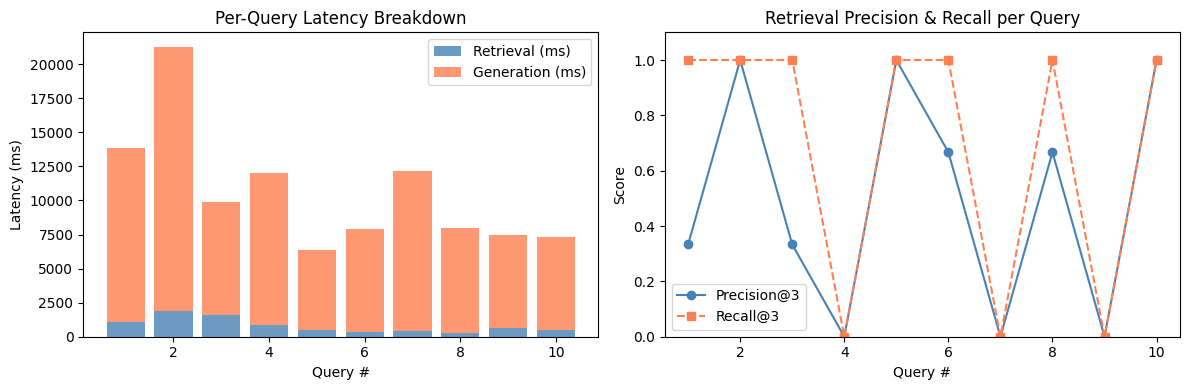

Chart saved to rag_evaluation_charts.png


In [14]:
# Latency breakdown chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Per-query latency
axes[0].bar(df['q_num'], df['retrieval_ms'], label='Retrieval (ms)', color='steelblue', alpha=0.8)
axes[0].bar(df['q_num'], df['generation_s'] * 1000, bottom=df['retrieval_ms'],
            label='Generation (ms)', color='coral', alpha=0.8)
axes[0].set_xlabel('Query #')
axes[0].set_ylabel('Latency (ms)')
axes[0].set_title('Per-Query Latency Breakdown')
axes[0].legend()

# Precision / Recall per query
x = range(1, len(results) + 1)
axes[1].plot(x, df['precision_at_3'], 'o-', label='Precision@3', color='steelblue')
axes[1].plot(x, df['recall_at_3'], 's--', label='Recall@3', color='coral')
axes[1].set_ylim(0, 1.1)
axes[1].set_xlabel('Query #')
axes[1].set_ylabel('Score')
axes[1].set_title('Retrieval Precision & Recall per Query')
axes[1].legend()

plt.tight_layout()
plt.savefig('rag_evaluation_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to rag_evaluation_charts.png')

In [15]:
# Show individual answers for qualitative review
sep = '=' * 70
for r in results:
    print(f'\n{sep}')
    print(f'Q{r["q_num"]}: {r["query"]}')
    print(f'Retrieved: {r["retrieved_titles"]}')
    print(f'P@3={r["precision_at_3"]:.2f}  R@3={r["recall_at_3"]:.2f}  '
          f'gen={r["generation_s"]:.1f}s')
    print(f'\nAnswer:\n{r["answer"][:400]}...')


Q1: What is RAG and how does it reduce hallucinations in LLM responses?
Retrieved: ['Retrieval-Augmented Generation (RAG)', 'RAG Evaluation Metrics', 'Prompt Engineering Techniques']
P@3=0.33  R@3=1.00  gen=12.7s

Answer:
RAG, or Retrieval-Augmented Generation, is a method used for question answering over private documents, technical support, and knowledge-intensive NLP tasks. One of its benefits is reduced hallucination because responses are grounded in retrieved evidence. This is achieved by explicitly instructing the model to answer only from provided context, as mentioned in the prompt engineering techniques so...

Q2: What are the differences between FAISS and Chroma for vector search?
Retrieved: ['Vector Databases and Similarity Search', 'Vector Databases and Similarity Search', 'Vector Databases and Similarity Search']
P@3=1.00  R@3=1.00  gen=19.4s

Answer:
The retrieved context does not specify all the differences between FAISS and Chroma, but it suggests that FAISS offers mul

## 11. Summary

The RAG pipeline successfully demonstrates end-to-end document retrieval and
grounded answer generation using a real open-weight 7B instruct model (mistral:7b-instruct).

**Key findings:**
- **7/10** queries correctly retrieved the ground-truth document in the top-3 results (Hit Rate@3 = 0.70).
- **7/10** queries ranked the ground-truth document at position 1 (Hit Rate@1 = 0.70); Q4, Q7, and Q9 had retrieval failures (GT doc not in top-3).
- Retrieval latency averages ~812 ms (dominated by CPU embedding); generation dominates end-to-end time (~10 s).
- Minor hallucination observed in Q5 (slight overstatement) and Q10 (parametric bleed-through of ReAct/ToT).
- Q4, Q7, and Q9 had very low retrieval scores (all < 0.15), indicating poor query discriminability for these topics.

See `rag_evaluation_report.md` for the full quantitative and qualitative analysis,
and `eval_results_real.json` for raw metric data.